# Dissipative Minima Sampling (DiMS) on the Snelson dataset

In this notebook we show how to run the **di**ssipative **m**inima **s**sampler (DiMS) for Pytorch-based models. We illustrate the sampler on the Snelson dataset.

Please follow the guide on initializing the environment provided in the README-file.

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

torch.set_default_dtype(torch.float64)

try:
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = 'serif'
except Exception:
    pass

In [2]:
# CONFIGURATIONS #
SEED        = 123
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = 'results/snelson'
os.makedirs(RESULTS_DIR, exist_ok=True)

# MODEL / TRAINING HYPERPARAMETERS #
HIDDEN_DIM   = 16
LR           = 1e-3
WEIGHT_DECAY = 1e-2
DROPOUT      = 0.2
N_EPOCHS     = 50_000
BATCH_SIZE   = 148

# LAPLACE HYPERPARAMETERS #
N_SAMPLES     = 10
N_HYPER_STEPS = 3_000

# GEOMETRY-AWARE SAMPLING HYPERPARAMETERS #
GEODESIC_RES = 501        # timesteps along each geodesic
T_RUN_RLA    = 1.0        # RLA stops at t=1 by definition
T_RUN_DIMS   = 50.0       # DiMS runs until convergence (friction dissipates energy)
FRICTION     = 0.1        # friction coefficient
N_JOBS       = 10         # for parallel geodesic sampling

## The Snelson dataset

We consider the Snelson dataset provided in the `data`-folder and remove points in the interval $x\in[1.5, 3]$ from the training set to explore out-of-distribution behavior under different sampling approaches. We construct the data loaders below.

Training data shape: torch.Size([148, 1]) torch.Size([148, 1])


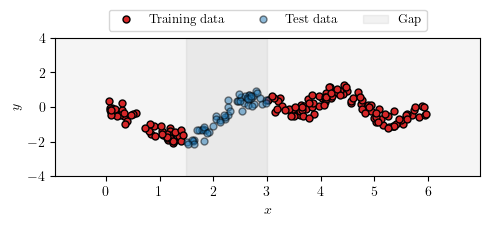

In [3]:
# Load the Snelson dataset
X_train = torch.tensor(np.loadtxt(f"data/snelson/train_inputs.txt").reshape(-1,1))  # (N, D)
y_train = torch.tensor(np.loadtxt(f"data/snelson/train_outputs.txt").reshape(-1,1)) # (N, 1)
X_pred = torch.tensor(np.loadtxt(f"data/snelson/test_inputs.txt").reshape(-1,1))   # (N, D)

# Define the gap in the training data set
in_between_idxs = torch.where(torch.logical_and(X_train >= 1.5, X_train <= 3))[0]
other_idxs = torch.where(torch.logical_or(X_train < 1.5, X_train > 3))[0]

# Split the data into training and test sets based on the gap
X_test = X_train[in_between_idxs]
y_test = y_train[in_between_idxs]
X_train = X_train[other_idxs]
y_train = y_train[other_idxs]

# Make dataloaders of X_trian and y_train for training
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print('Training data shape:', X_train.shape, y_train.shape)


# Plot the training and test data, highlighting the gap
x_min, x_max = X_train.min().item(), X_train.max().item()

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(X_train.cpu(), y_train.cpu(), 'o', color='tab:red', mec='k', markersize=5, label='Training data')
ax.plot(X_test.cpu(), y_test.cpu(), 'o', color='tab:blue', mec='k', markersize=5, label='Test data', alpha=0.5)
ax.axvspan(1.5, 3, color='grey', alpha=0.1, label='Gap')
ax.set_xlim(x_min - 1, x_max + 1)
ax.set_ylim(-4, 4)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_facecolor('whitesmoke')
ax.legend(fontsize=9, ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.25))
plt.tight_layout()
plt.show()

## Model and MAP Training

Next, we train a four-layer MLP with GELU activations and dropout based on a log-joint minimization objective - i.e. we minimize the MSE loss and introduce regularization, thus the setting corresponds to a Gaussian likelihood and prior. We train until convergence.

In [4]:
# Set random seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# Define a simple model
model = nn.Sequential(
    nn.Linear(1, HIDDEN_DIM, bias=True),
    nn.GELU(),
    nn.Dropout(DROPOUT),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM, bias=True),
    nn.GELU(),
    nn.Dropout(DROPOUT),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM, bias=True),
    nn.GELU(),
    nn.Dropout(DROPOUT),
    nn.Linear(HIDDEN_DIM, 1, bias=True)
).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

# Set up the optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss(reduction='sum')

# Train the model
model.train()
pbar = tqdm(range(N_EPOCHS), desc='Training')
for epoch in pbar:
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch).flatten(), y_batch.flatten())
        loss.backward()
        optimizer.step()
    if epoch % 5_000 == 0:
        pbar.set_postfix(loss=f'{loss.item():.4f}')

print(f'Final loss: {loss.item():.6f}')
pbar.close()

Parameters: 593


Training:   0%|          | 0/50000 [00:00<?, ?it/s]

Final loss: 15.364606


We now have access to a MAP estimate, $\boldsymbol{\theta}^\ast$, from which we will initialize the sampling schemes. First, we plot the function induced by the MAP estimate. 

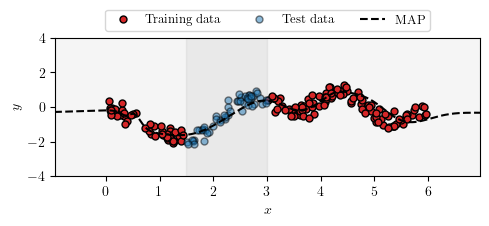

In [5]:
# Set the model in evaluation mode
model.eval()

# Get the model predictions on the test set
with torch.no_grad():
    y_map = model(X_pred).cpu().numpy()

# Plot the function space MAP estimate along with the training and test data, highlighting the gap
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(X_train.cpu(), y_train.cpu(), 'o', color='tab:red', mec='k', markersize=5, label='Training data')
ax.plot(X_test.cpu(), y_test.cpu(), 'o', color='tab:blue', mec='k', markersize=5, label='Test data', alpha=0.5)
ax.plot(X_pred.cpu(), y_map, '--', color='k', label='MAP')
ax.axvspan(1.5, 3, color='grey', alpha=0.1)
ax.set_xlim(x_min - 1, x_max + 1)
ax.set_ylim(-4, 4)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.legend(fontsize=9, ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.25))
ax.set_facecolor('whitesmoke')
plt.tight_layout()
plt.show()

## Laplace Approximation

We fit a full-Hessian Laplace approximation over all weights and jointly optimise the prior precision and noise variance via marginal-likelihood maximisation. To define the approximate posterior, we rely on the `laplace-torch` library.

In [6]:
from laplace import Laplace

# Set the model in evaluation mode before fitting the Laplace approximation
model.eval()

# Get the MAP estimate in parameter space as the mode of the Laplace approximation
map_solution = torch.nn.utils.parameters_to_vector(
    model.parameters()).detach().clone()

# Define the Laplace approximation around the MAP solution
la = Laplace(
    model, 'regression',
    subset_of_weights='all',
    hessian_structure='full',
    prior_precision=2*WEIGHT_DECAY,
)
# Fit the Laplace approximation to the training data
la.fit(train_loader)

# Optimize the hyperparameters of the Laplace approximation
log_prior, log_sigma = torch.ones(1, requires_grad=True), torch.ones(1, requires_grad=True)
hyper_optimizer = torch.optim.Adam([log_prior, log_sigma], lr=1e-2)
for i in tqdm(range(3000), desc='Optimizing hyperparameters...'):
    hyper_optimizer.zero_grad()
    neg_marglik = -la.log_marginal_likelihood(prior_precision=log_prior.exp(), sigma_noise=log_sigma.exp())
    neg_marglik.backward()
    hyper_optimizer.step()

# Update the Laplace approximation with the optimized hyperparameters
la.prior_precision = log_prior.exp().detach().clone()
la.sigma_noise = log_sigma.exp().detach().clone()

# Print the optimized hyperparameters
print(f'Optimized prior precision: {la.prior_precision.item():.4f}')
print(f'Optimized noise variance: {la.sigma_noise.item():.4f}')

/Users/akjja/miniconda3/envs/dims/lib/python3.12/site-packages/curvlinops/_base.py:299: UserWarning: Input matrix is float64, while linear operator is float32. Converting to float32.
  warn(


Optimizing hyperparameters...:   0%|          | 0/3000 [00:00<?, ?it/s]

Optimized prior precision: 0.0793
Optimized noise variance: 0.4205


With the fine-tuned Laplace approximation (LA) we can now draw samples that will also later serve as the initial velocity samples for the geometry-based sampling schemes.

In [7]:
# Define the Laplace approximation as a zero-centered Gaussian in parameter space
# Samples will later be shifted by the MAP solution
q = torch.distributions.MultivariateNormal(
    loc=torch.zeros_like(map_solution),
    scale_tril=la.posterior_scale.detach().clone().to(DEVICE),
)

# Draw initial velocity samples from the distribution
torch.manual_seed(SEED)
laplace_samples = q.rsample((N_SAMPLES,))  # (N_SAMPLES, K)
print(f'Laplace sample shape: {tuple(laplace_samples.shape)}')

Laplace sample shape: (10, 593)


## The manifold object

We have now come to the crucial part of the implementation; *the manifold object*. We implemented the basic dynamics and definitions of manifolds defined as the graph of a function in the `EmbeddedLossManifold`-class, and construct a specific instance below, namely the `RegressionManifold`-class. This is defined as the log-joint of a Gaussian likelihood and prior where the variance and prior precision are determined above in the hyperparameter optimization step.

The critical functionalities of the class are:
- `.predict(params, X)` that takes a tensor of parameters related to the network architecture and outputs the associated predictions on `X`.
- `.loss_fn(params, X, y)` that leverages the `predict`-method to compute the associated loss on the input data `X` and `y`.

In [8]:
from geomtools.geometry import EmbeddedLossManifold

class RegressionManifold(EmbeddedLossManifold):
    def __init__(self, network, solver='dopri5', rtol=1e-7, atol=1e-9, reduction='sum', weight_subset=None, prior_precision=0.0, noise_variance=1.0):
        super().__init__(network=network, solver=solver, atol=atol, rtol=rtol, reduction=reduction, weight_subset=weight_subset)
        self.reduction = reduction
        self.network = network
        self.prior_precision = prior_precision
        self.noise_variance = noise_variance

    def predict(self, params, X):
        # Concatenate the optimized parameters with the remaining fixed parameters to get the full parameter vector for the network
        if self.ignore_ordering:
            p = params
        else:
            p = torch.concatenate([params.flatten(), self.remaining_params])
            p = torch.index_select(p, 0, self.order) # order correctly for the network

        # Build the network parameters without breaking graph
        param_dict = {name: chunk.view_as(w) for name, chunk, w in zip(self.param_names, p.split([w.numel() for w in self.params_structure]), self.params_structure)}
        return torch.func.functional_call(self.network, param_dict, (X,))

    def loss_fn(self, params, **kwargs):
        # Extract the data from kwargs
        X, y = kwargs['X'], kwargs['y']

        # Compute the loss value (negative log likelihood under Gaussian noise model)
        loss_value = (self.predict(params, X) - y).pow(2) / (2 * self.noise_variance)
        
        # Add L2 regularization term to the loss --> equivalent to a diagonal Gaussian prior on the parameters
        neg_log_prior = (0.5 * self.prior_precision * params.pow(2).sum()).squeeze() # sum over all parameters, then remove extra dimensions
        # Return the total loss value (negative log posterior)
        loss_value = (loss_value.mean() if self.reduction == 'mean' else loss_value.sum()) + neg_log_prior
        return loss_value

After defining the manifold class, we can instantiate it with the desired solver and precision, based on the `torchdiffeq` library. Remark that these choices are critical for obtaining reliable geometry-aware samples.

In [9]:
manifold = RegressionManifold(
    network=model,
    solver='dopri5',
    atol=1e-6,
    rtol=1e-7,
    reduction='sum',
    prior_precision=la.prior_precision.detach().clone(),
    noise_variance=la.sigma_noise.detach().clone().pow(2),
)

## Geometry-aware sampling

Each centred Laplace sample is used as an initial velocity at $\boldsymbol{\theta}^\ast$. Integrating the dynamical system on the loss manifold for time $t$ yields a posterior sample. We therefore define a function for obtaining geometry-aware samples for a batch of initial velocity samples. For improving the computational efficiency, we parallelize the computation of multiple samples using `joblib`. Remark that our implementation supports solving a batch of curve equations simultaneously, however, this can be computationally hard since `torchdiffeq` relies on a adaptive step-size based on the worst-case sample within the batch. 

In [10]:
from joblib import Parallel, delayed

def sample_geodesics(init_vs, t_run, correction, friction_coeff=None, gravity_coeff=1.0, n_jobs=-1):
    return torch.stack(Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(lambda v: manifold.geodesic(
            position=map_solution, 
            init_vs=v,
            geodesic_res=GEODESIC_RES,
            X=X_train, 
            y=y_train, 
            correction=correction, 
            friction_coeff=friction_coeff,
            gravity_coeff=gravity_coeff,
            t_run=t_run,
            parallel="joblib",
        )[0].squeeze(1))(v)
        for v in init_vs
    ), axis=0)

Given the sampling function, we now set $t=1$ and sample according to the dynamics of the geodesic equation. In other words, this gives us samples from the *Riemannian Laplace approximation (**RLA**).*

In [11]:
# Define the RLA path
rla_path = os.path.join(RESULTS_DIR, 'rla_samples.pt')

if os.path.exists(rla_path): # load samples if they exist
    rla_samples = torch.load(rla_path, map_location=DEVICE)
    print(f'Loaded RLA samples  {tuple(rla_samples.shape)}')

else: # otherwise compute and save them
    t0 = time.time()
    rla_samples = sample_geodesics(laplace_samples, t_run=T_RUN_RLA, correction=None, n_jobs=N_JOBS)
    torch.save(rla_samples, rla_path)
    print(f'RLA done in {time.time()-t0:.1f}s — saved to {rla_path}')

RLA done in 193.1s — saved to results/snelson/rla_samples.pt


Next, we turn our attention towards the DiMS sampler, that samples according to a different dynamical system that introduces gravitataional and friction forces.

In [12]:
# Define the DiMS path
dims_path = os.path.join(RESULTS_DIR, 'dims_samples.pt')

if os.path.exists(dims_path): # load samples if they exist
    dims_samples = torch.load(dims_path, map_location=DEVICE)
    print(f'Loaded DiMS samples {tuple(dims_samples.shape)}')

else: # otherwise compute and save them
    t0 = time.time()
    dims_samples = sample_geodesics(
        laplace_samples, t_run=T_RUN_DIMS,
        correction='kinetic_friction', friction_coeff=FRICTION,
        n_jobs=N_JOBS
    )
    torch.save(dims_samples, dims_path)
    print(f'DiMS done in {time.time()-t0:.1f}s — saved to {dims_path}')

DiMS done in 237.1s — saved to results/snelson/dims_samples.pt


## Evaluating the samples

We first evaluate the two geometry-aware samples against each other based on visual inspection of the function space samples induced by each of the methods. For this reason, we use the `.predict`-method to obtain posterior predictive samples.

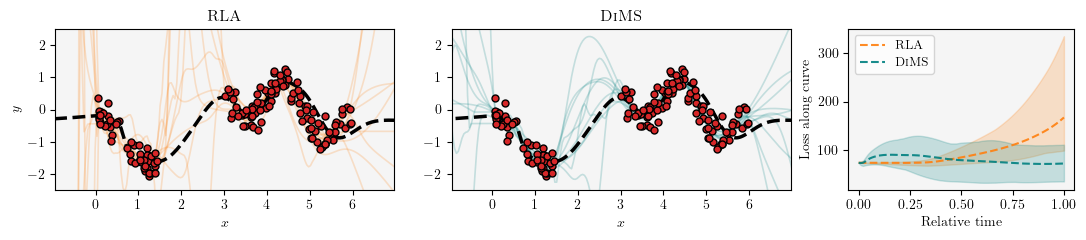

In [13]:
# Setup for the figure
COLORS = ['tab:orange', 'teal']
fig, axs = plt.subplots(1, 3, figsize=(11, 2.5), gridspec_kw={'width_ratios': [1.5, 1.5, 1]})
ts = torch.linspace(0, 1, GEODESIC_RES)

# Iterate over sampling methods
for c, (samples, label) in enumerate([(rla_samples.to(DEVICE),  r'\textsc{RLA}'), (dims_samples.to(DEVICE), r'\textsc{DiMS}')]):
    with torch.no_grad():
        # Get the posterior predictive of the samples on the full input space grid
        preds = torch.vmap(
            lambda s: manifold.predict(s, X=X_pred).flatten()
        )(samples[:, -1, :]).cpu()   # (N, n_pred)

    # Plot the predictions
    for pred in preds:
        axs[c].plot(X_pred.cpu(), pred.numpy(), color=COLORS[c], alpha=0.2, linewidth=1.2)

    # Plot the data and make it look crisp
    axs[c].plot(X_pred.cpu(), y_map, '--', color='k', linewidth=2.5, label='MAP')
    axs[c].plot(X_train.cpu(), y_train.cpu(), 'o', color='tab:red', mec='k', markersize=5, zorder=5, label='Training data')
    axs[c].set_xlim(x_min - 1, x_max + 1)
    axs[c].set_ylim(-2.5, 2.5)
    axs[c].set_title(label, fontsize=11)
    axs[c].set_facecolor('whitesmoke')
    axs[c].set_xlabel('$x$')
    if c == 0:
        axs[c].set_ylabel('$y$')

    # Compute the loss along the curves to visualize the energy landscape traversal
    loss_curves = torch.vmap(
        lambda p: manifold.loss_fn(p, X=X_train.to(DEVICE), y=y_train.to(DEVICE))
    )(samples.flatten(end_dim=-2)).reshape(len(samples), GEODESIC_RES).cpu()

    # Plot the mean loss traversal and a 95% confidence interval across the sampled curves
    mean_loss = loss_curves.mean(dim=0)
    q_low  = np.percentile(loss_curves.numpy(), 2.5,  axis=0)
    q_high = np.percentile(loss_curves.numpy(), 97.5, axis=0)
    axs[2].plot(ts, mean_loss, color=COLORS[c], linestyle='--', alpha=0.9, label=label)
    axs[2].fill_between(ts, q_low, q_high, color=COLORS[c], alpha=0.2)
    axs[2].set_facecolor('whitesmoke')

# Add labels and legend to the loss panel
axs[2].set_xlabel('Relative time')
axs[2].set_ylabel('Loss along curve')
axs[2].legend(fontsize=9, loc='upper left')

# Nudge the loss panel slightly rightward so it doesn't crowd the middle panel
pos = axs[2].get_position()
axs[2].set_position([pos.x0 + 0.005, pos.y0, pos.width, pos.height])

# Make the layout tight and save the figure
plt.tight_layout()
plt.show()

Next, we evaluate the negative log-likelihood on the training and test sets to quantitatively compare the methods.

In [14]:
criterion_nll = nn.GaussianNLLLoss(reduction='none')

for (X_, y_, split) in [(X_train, y_train, 'train'), (X_test, y_test, 'test')]:
    print(f'\n{"#"*10} Negative log-likelihood on {split} set {"#"*10}')
    for samples, label in [(rla_samples.to(DEVICE), 'RLA'), (dims_samples.to(DEVICE), 'DiMS')]:
        endpoints = samples[:, -1, :]  # (N, K)
        with torch.no_grad():
            y_pred = torch.vmap(
                lambda s: manifold.predict(s, X=X_)

        )(endpoints)  # (N, n_train, 1)

        var = torch.full_like(y_pred, manifold.noise_variance.item())
        nll = criterion_nll(y_pred, y_.unsqueeze(0).expand_as(y_pred), var)
        nll_per_sample = nll.mean(dim=1).squeeze(-1)   # (N,)
        print(f'{label} NLL = {nll_per_sample.mean():.3f} ± {nll_per_sample.std() / nll_per_sample.shape[0]**0.5:.3f}')


########## Negative log-likelihood on train set ##########
RLA NLL = -0.357 ± 0.110
DiMS NLL = -0.634 ± 0.006

########## Negative log-likelihood on test set ##########
RLA NLL = 78.082 ± 55.942
DiMS NLL = 1.816 ± 0.945


### Comparison to Laplace and Linearized Laplace

Other common methods include the sampled Laplace approximation (LA) and the linearized Laplace approximation. We can easily evaluate the sampled Laplace approximation, while the linearized Laplace approximation requires computing Jacobian-vector products. This is however also easy using automatic differentiation, as we show below.

In [15]:
# Define the tangent space samples for the linearized Laplace approximation
deltas = laplace_samples

# Compute the tangent vectors at the MAP solution corresponding to each Laplace sample
tangents = torch.stack([
    torch.func.jvp(lambda s: manifold.predict(s, X=X_pred), (map_solution,), (dtheta,))[1]
    for dtheta in deltas 
], dim=0)

# Get the function space MAP estimate
f_map = manifold.predict(map_solution, X=X_pred)
# Compute the linearized Lacplace samples in function space by adding the tangent vectors to the MAP prediction
lin_laplace_samples = f_map.unsqueeze(0) + tangents 

# Define a dictionary to hold the function space samples for each method for easy plotting and comparison
fs_samples = {
    'LA': torch.vmap(lambda s: manifold.predict(s, X=X_pred))(laplace_samples + map_solution),  # (N_SAMPLES, n_pred, out_dim)
    'LinLA': lin_laplace_samples,
    'RLA': torch.vmap(lambda s: manifold.predict(s, X=X_pred))(rla_samples[:, -1, :]),
    'DiMS': torch.vmap(lambda s: manifold.predict(s, X=X_pred))(dims_samples[:, -1, :]),
}

We plot the resulting function space samples below.

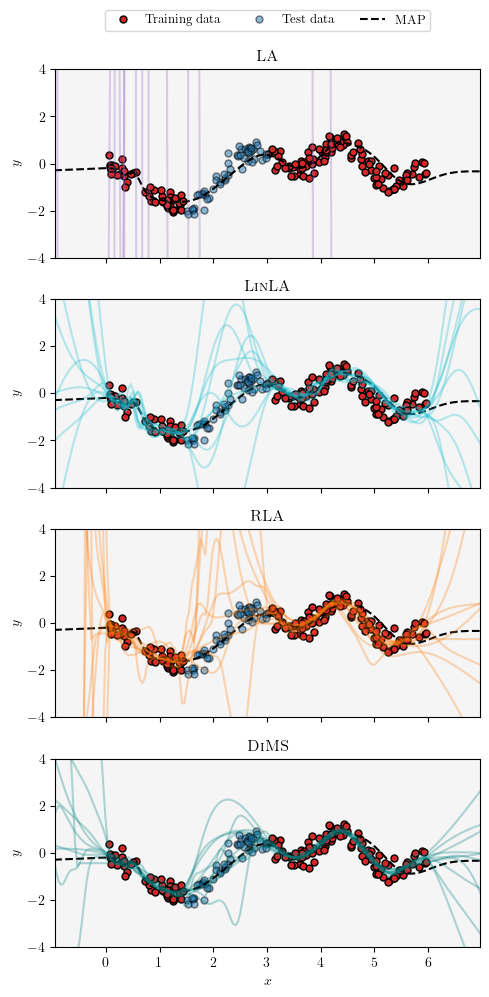

In [16]:
COLORS = {'LA': 'tab:purple', 'LinLA': 'tab:cyan', 'RLA': 'tab:orange', 'DiMS': 'teal'}

fig, axs = plt.subplots(4, 1, figsize=(5, 10), sharex=True)
for c, (label, samples) in enumerate(fs_samples.items()):
    ax = axs[c]
    ax.plot(X_train.cpu(), y_train.cpu(), 'o', color='tab:red', mec='k', markersize=5, label='Training data')
    ax.plot(X_test.cpu(), y_test.cpu(), 'o', color='tab:blue', mec='k', markersize=5, label='Test data', alpha=0.5)
    ax.plot(X_pred.cpu(), y_map, '--', color='k', label='MAP')

    for pred in samples:
        ax.plot(X_pred.cpu(), pred.detach().cpu().numpy(), color=COLORS[label], alpha=0.3)

    ax.set_xlim(x_min - 1, x_max + 1)
    ax.set_ylim(-4, 4)
    ax.set_ylabel('$y$')
    ax.set_facecolor('whitesmoke')
    ax.set_title(fr'\textsc{{{label}}}', fontsize=11)
    
    if c == 0:
        ax.legend(fontsize=9, ncols=3, loc='upper center', bbox_to_anchor=(0.5, 1.35))
    
ax.set_xlabel('$x$')
plt.tight_layout()
plt.show()


### Extra: visualing function space samples along sampling trajectories

In [17]:
from matplotlib.animation import FuncAnimation

def animate_function_samples(manifold, rla_samples, dims_samples, X_plot,
                            X_train=None, y_train=None, X_test=None, y_test=None,
                            y_map=None, x_min=None, x_max=None,
                            interval=150, figsize=(10, 2.5), alpha=0.2):
    """
    Animate RLA and DiMS function-space samples side by side over geodesic time.

    rla_samples, dims_samples : Tensor (S, T, D)
    X_plot : Tensor (N, 1) — input grid for predictions
    """
    COLORS = ['tab:orange', 'teal']
    labels = [r'\textsc{RLA}', r'\textsc{DiMS}']

    S, T, D = rla_samples.shape
    X_plot = X_plot if isinstance(X_plot, torch.Tensor) else torch.tensor(X_plot, dtype=torch.float64)
    x_np = X_plot.squeeze().cpu().numpy()

    # Pre-compute all predictions: list of (T, S, N) for each method
    all_preds = []
    for samples in [rla_samples, dims_samples]:
        preds = []
        with torch.no_grad():
            for t in range(T):
                preds_t = torch.vmap(lambda s: manifold.predict(s, X_plot).flatten())(samples[:, t, :]).cpu()
                preds.append(preds_t)
        all_preds.append(torch.stack(preds).numpy())  # (T, S, N)

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    for ax, color, label in zip(axs, COLORS, labels):
        ax.set_facecolor('whitesmoke')
        ax.set_xlim((x_min if x_min else x_np.min()) - 1, (x_max if x_max else x_np.max()) + 1)
        ax.set_ylim(-2.5, 2.5)
        ax.set_xlabel('$x$')
        ax.set_title(label, fontsize=11)

    axs[0].set_ylabel('$y$')

    # Static elements
    for ax, color, preds in zip(axs, COLORS, all_preds):
        if y_map is not None:
            ax.plot(x_np, y_map if isinstance(y_map, np.ndarray) else y_map.cpu().numpy(),
                    '--', color='k', linewidth=2.5, label='MAP', zorder=4)
        if X_test is not None and y_test is not None:
            ax.plot(X_test.cpu(), y_test.cpu(), 'o', color='tab:blue', mec='k', markersize=5, alpha=0.5, zorder=5)
        if X_train is not None and y_train is not None:
            ax.plot(X_train.cpu(), y_train.cpu(), 'o', color='tab:red', mec='k', markersize=5, zorder=5, label='Training data')

    # Animated lines
    sample_lines = [
        [ax.plot(x_np, all_preds[c][0, s], color=color, alpha=alpha, linewidth=1.2)[0]
        for s in range(S)]
        for c, (ax, color) in enumerate(zip(axs, COLORS))
    ]
    # time_text = fig.text(0.5, 1.0, 't = 0', ha='center', va='top', fontsize=10)
    
    fig.suptitle('$Time index = 0$', fontsize=11)
    plt.tight_layout()

    def update(t):
        for c, lines in enumerate(sample_lines):
            for s, line in enumerate(lines):
                line.set_ydata(all_preds[c][t, s])
        fig.suptitle(f'Time index $= {t}$', fontsize=11)
        return [line for lines in sample_lines for line in lines]

    anim = FuncAnimation(fig, update, frames=T, interval=interval, blit=True)
    return anim

anim = animate_function_samples(
    manifold, rla_samples, dims_samples, X_pred,
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
    y_map=y_map, x_min=x_min, x_max=x_max,
)   
anim.save('figures/samples_animation.gif', writer='pillow', fps=30)
plt.close()